## Visualizing motif enrichment results using `anno_img`

In [1]:
import os,sys
import matplotlib.pylab as plt
import pickle
import glob
import numpy as np
import matplotlib as mpl
import pandas as pd
mpl.style.use('default')
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Arial'
mpl.rcParams['figure.dpi'] = 80
mpl.rcParams['savefig.dpi']=300
import pickle
# sys.path.append(os.path.expanduser("~/Projects/Github/PyComplexHeatmap"))
from PyComplexHeatmap import (
    ClusterMapPlotter,DotClustermapPlotter,HeatmapAnnotation,anno_simple,anno_scatterplot,anno_lineplot,anno_barplot,
    anno_label,anno_boxplot,anno_img,
)

Read data

In [2]:
with open("../data/anno_img_example.pickle",'rb') as f:
    data,df_row,df_col,colors=pickle.load(f)

In [3]:
data

,MajorType,Gene,frac,median
0,ASC,Bach1,0.141686,0.755535
1,ASC,Barhl1,0.977752,0.114052
2,ASC,Ebf1,0.000000,0.701078
3,ASC,Ebf4,0.221311,0.616565
4,ASC,Emx1,0.748244,0.370591
...,...,...,...,...
589,VLMC-Pia,Sox10,0.393939,0.584046
590,VLMC-Pia,Sox8,0.661616,0.388624
591,VLMC-Pia,Spi1,0.075758,0.728079
592,VLMC-Pia,Tcf4,0.005051,0.733103


In [4]:
df_row

,groupA,auc_score,FC,DeltaMean,ID,Logo
Gene,,,,,,
Nfia,ASC,0.867084,0.767527,-0.149461,ASC|Nfia,https://motifcollections.aertslab.org/v10nr_cl...
Tcf4,CGE-Vip,0.941525,0.508175,-0.282496,CGE-Vip|Tcf4,https://motifcollections.aertslab.org/v10nr_cl...
Erg,EC,0.905526,0.857981,-0.114057,EC|Erg,https://motifcollections.aertslab.org/v10nr_cl...
Fli1,EC,0.865978,0.747177,-0.171242,EC|Fli1,https://motifcollections.aertslab.org/v10nr_cl...
Zbtb43,Exc,0.685494,0.784200,-0.144034,Exc|Zbtb43,https://motifcollections.aertslab.org/v10nr_cl...
Mef2c,IT-L6,0.801657,0.680693,-0.177612,IT-L6|Mef2c,https://motifcollections.aertslab.org/v10nr_cl...
Spi1,MGC,0.834667,0.736412,-0.185941,MGC|Spi1,https://motifcollections.aertslab.org/v10nr_cl...
Hdx,MGC,0.761553,0.852639,-0.120034,MGC|Hdx,https://motifcollections.aertslab.org/v10nr_cl...
Bach1,MGE-Pvalb,0.661613,0.855795,-0.100834,MGE-Pvalb|Bach1,https://motifcollections.aertslab.org/v10nr_cl...


In [5]:
df_col

,CellClass
MajorType,
ASC,NonN
MGC,NonN
UL-P2,P
MGE-MN,P
DL-P2,P
IT-L5,Exc
MGE-Pvalb,Inh
UL-P1,P
CT-L6,Exc


In [6]:
# # download image to local
# import requests
# img_dir='images'
# if not os.path.exists(img_dir):
#     os.mkdir(img_dir)
# for url in df_row.Logo.tolist():
#     img_data = requests.get(url).content
#     file=os.path.basename(url)
#     with open(os.path.join(img_dir,file), 'wb') as handler:
#         handler.write(img_data)

In [7]:
img_dir='images'
df_row.Logo=df_row.Logo.apply(lambda x:os.path.join(img_dir,os.path.basename(x)))
df_row

,groupA,auc_score,FC,DeltaMean,ID,Logo
Gene,,,,,,
Nfia,ASC,0.867084,0.767527,-0.149461,ASC|Nfia,images/jaspar__MA0670.1.png
Tcf4,CGE-Vip,0.941525,0.508175,-0.282496,CGE-Vip|Tcf4,images/tfdimers__MD00119.png
Erg,EC,0.905526,0.857981,-0.114057,EC|Erg,images/metacluster_135.7.png
Fli1,EC,0.865978,0.747177,-0.171242,EC|Fli1,images/metacluster_135.7.png
Zbtb43,Exc,0.685494,0.784200,-0.144034,Exc|Zbtb43,images/metacluster_131.8.png
Mef2c,IT-L6,0.801657,0.680693,-0.177612,IT-L6|Mef2c,images/transfac_pro__M04846.png
Spi1,MGC,0.834667,0.736412,-0.185941,MGC|Spi1,images/metacluster_167.5.png
Hdx,MGC,0.761553,0.852639,-0.120034,MGC|Hdx,images/tfdimers__MD00488.png
Bach1,MGE-Pvalb,0.661613,0.855795,-0.100834,MGE-Pvalb|Bach1,images/jaspar__MA1633.2.png


Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 123.77287453405835
Plotting legends..


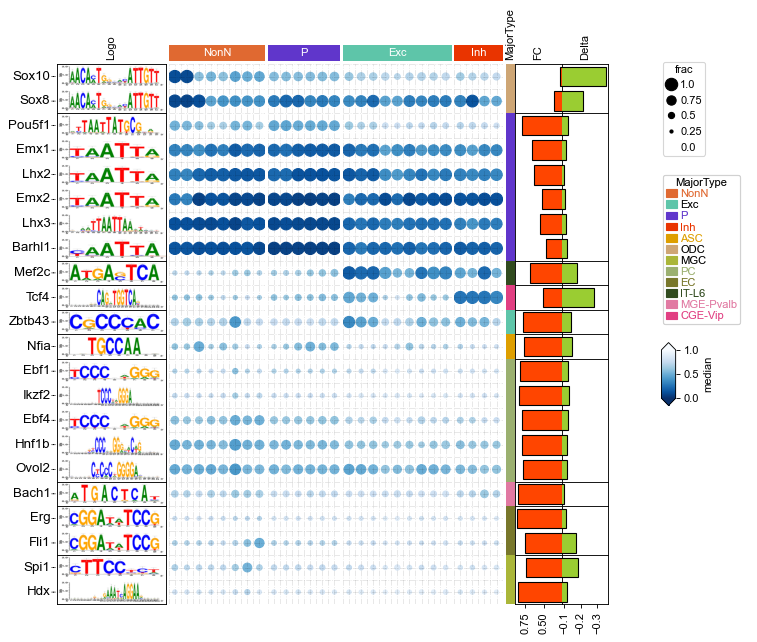

In [11]:
left_ha = HeatmapAnnotation(
    label=anno_label(df_row.index.to_series(), merge=True,rotation=0,relpos=(1,0.5),arrowprops=dict(visible=True),
                  fontsize=12,luminance=0.8,height=2,colors='black'),
    Logo=anno_img(df_row.Logo,border_width=0,height=35,
                 ),
    axis=0, verbose=0,orientation='left',#label_kws={'horizontalalignment': 'left', 'visible': True}
)

right_ha = HeatmapAnnotation(
    # Logo=anno_img(df_row.Logo,border_width=5,border_color=255,height=25,invert_x=False,invert_y=False),
    MajorType=anno_simple(df_row.groupA, add_text=False, legend=True, colors=colors),
    FC=anno_barplot(df_row.FC,colors='orangered',legend=False,height=15),
    Delta=anno_barplot(df_row.DeltaMean,colors='yellowgreen',legend=False,height=15),
    axis=0, verbose=0, orientation='left',#label_kws={'horizontalalignment': 'left', 'visible': True}
)

col_ha = HeatmapAnnotation(
    CellClass=anno_simple(df_col.CellClass, colors=colors,legend=False, add_text=True,height=4.5),
    verbose=0, label_side='right', label_kws={'horizontalalignment': 'left','visible':False})

plt.figure(figsize=(9, 8))
cm = DotClustermapPlotter(data=data, x='MajorType', y='Gene', value='median', c='median',
                          s='frac',cmap='Blues_r',
                          row_cluster=True, col_cluster=True, #hue='Group',
                          # cmap={'Group1': 'Greens', 'Group2': 'OrRd'},
                          vmin=0, vmax=1,
                          # colors={'Group1': 'yellowgreen', 'Group2': 'orange'},
                          # marker={'Group1': '*', 'Group2': '$\\ast$'},
                          #show_rownames=True, show_colnames=True, row_dendrogram=False,
                          #col_names_side='bottom',  row_names_side='left',
                          xticklabels_kws={'labelrotation': -90, 'labelcolor': 'blue', 'labelsize': 14},
                          yticklabels_kws={'labelcolor': 'black', 'labelsize': 14},
                          top_annotation=col_ha, right_annotation=right_ha,left_annotation=left_ha,
                          spines=False,
                          row_split=df_row.groupA, row_split_gap=0,
                          col_split=df_col.CellClass, col_split_gap=0.8,
                          verbose=1, legend_vgap=6,legend_hpad=0,legend_width=28,
                          # dot_legend_marker='*',
                          # xlabel=Group,xlabel_side="top",
                          # xlabel_kws=dict(labelpad=8,fontweight='bold'),
                          # xlabel_bbox_kws=dict(facecolor=facecolor)
                          )
for ax in cm.heatmap_axes.ravel():
    ax.grid(axis='both', which='major', color='black', linestyle='dashdot', alpha=0.1,zorder=-10)
# plt.savefig(f"{outname}.dotHeatmap.pdf",bbox_inches='tight')
plt.show()

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..
Inferred max_s (max size of scatter point) is: 147.95012429626684
Plotting legends..


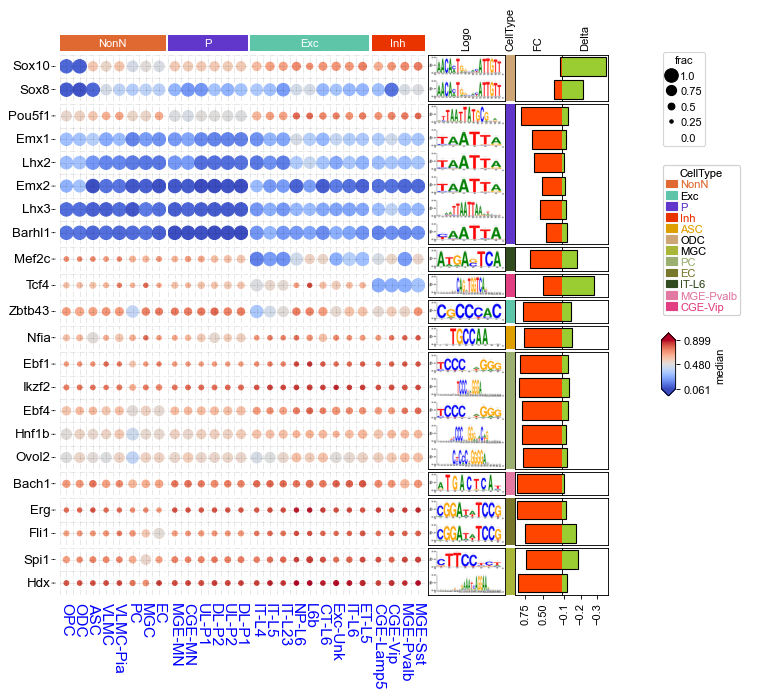

In [12]:
left_ha = HeatmapAnnotation(
    label=anno_label(df_row.index.to_series(), merge=True,rotation=0,relpos=(1,0.5),arrowprops=dict(visible=True),
                  fontsize=12,luminance=0.8,height=2,colors='black'),
    # Logo=anno_img(df_row.Logo,border_width=0,border_color=255,height=35,rotate=180),
    axis=0, verbose=0,orientation='left',#label_kws={'horizontalalignment': 'left', 'visible': True}
)

right_ha = HeatmapAnnotation(
    Logo=anno_img(df_row.Logo,border_width=1,height=25),
    CellType=anno_simple(df_row.groupA, add_text=False, legend=True, colors=colors),
    FC=anno_barplot(df_row.FC,colors='orangered',legend=False,height=15),
    Delta=anno_barplot(df_row.DeltaMean,colors='yellowgreen',legend=False,height=15),
    axis=0, verbose=0, orientation='left',#label_kws={'horizontalalignment': 'left', 'visible': True}
)

col_ha = HeatmapAnnotation(
    CellClass=anno_simple(df_col.CellClass, colors=colors,legend=False, add_text=True,height=4.5),
    verbose=0, label_side='right', label_kws={'horizontalalignment': 'left','visible':False})

plt.figure(figsize=(9, 8))
cm = DotClustermapPlotter(data=data, x='MajorType', y='Gene', value='median', c='median',
                          s='frac',cmap='coolwarm',
                          row_cluster=True, col_cluster=True, #hue='Group',
                          # cmap={'Group1': 'Greens', 'Group2': 'OrRd'},
                          # vmin=0, vmax=1,
                          # colors={'Group1': 'yellowgreen', 'Group2': 'orange'},
                          # marker={'Group1': '*', 'Group2': '$\\ast$'},
                          show_colnames=True, #show_colnames=True, row_dendrogram=False,
                          col_names_side='bottom',  row_names_side='left',
                          xticklabels_kws={'labelrotation': -90, 'labelcolor': 'blue', 'labelsize': 14},
                          yticklabels_kws={'labelcolor': 'black', 'labelsize': 14},
                          top_annotation=col_ha, right_annotation=right_ha,left_annotation=left_ha,
                          spines=False,
                          row_split=df_row.groupA, row_split_gap=0.8,
                          col_split=df_col.CellClass, col_split_gap=0.8,
                          verbose=1, legend_vgap=6,legend_hpad=0,legend_width=28,
                          # dot_legend_marker='*',
                          # xlabel=Group,xlabel_side="top",
                          # xlabel_kws=dict(labelpad=8,fontweight='bold'),
                          # xlabel_bbox_kws=dict(facecolor=facecolor)
                          )
for ax in cm.heatmap_axes.ravel():
    ax.grid(axis='both', which='major', color='black', linestyle='dashdot', alpha=0.1,zorder=-10)

# ax=right_ha.annotations[0].ax
# ax.xaxis.set_visible(True) # show ticks
# ax.tick_params(
#     axis="x", which="both", bottom=True, labelbottom=True
# )
# for side in ["top", "right", "left", "bottom"]:
#     ax.set_axis_on()
#     ax.spines[side].set_visible(True)
#     ax.spines[side].set_color('red')
#     ax.spines[side].set_linewidth(1)
#     ax.spines[side].set_linestyle('--')
plt.savefig("motif_tf.dotHeatmap.pdf",bbox_inches='tight')
plt.show()